In [1]:

import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    KFold,
    StratifiedKFold
)


# Linear Models
from sklearn.linear_model import (
    LogisticRegression,
    Ridge,
    Lasso
)

# Tree-based
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)

# SVM
from sklearn.svm import SVC, SVR

# Neighbors
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Dimensionality Reduction
from sklearn.decomposition import PCA

# -------------------------------
# Metrics (ALL major ones)
# -------------------------------
from sklearn.metrics import (
    # Classification
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    log_loss,

    # Regression
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    max_error,
    median_absolute_error,
    explained_variance_score,

    # Clustering
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score
)

# -------------------------------
# Visualization
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("final_cleaned_dataset.csv")#reading the csv

In [3]:
df.shape

(1438951, 35)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1438951 entries, 0 to 1438950
Data columns (total 35 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   id                     1438951 non-null  str    
 1   vendor_id              1438951 non-null  int64  
 2   passenger_count        1438951 non-null  int64  
 3   pickup_longitude       1438951 non-null  float64
 4   pickup_latitude        1438951 non-null  float64
 5   dropoff_longitude      1438951 non-null  float64
 6   dropoff_latitude       1438951 non-null  float64
 7   store_and_fwd_flag     1438951 non-null  str    
 8   trip_duration          1438951 non-null  int64  
 9   pickup_hour            1438951 non-null  int64  
 10  pickup_day             1438951 non-null  int64  
 11  pickup_month           1438951 non-null  int64  
 12  pickup_day_of_week     1438951 non-null  int64  
 13  dropoff_hour           1438951 non-null  int64  
 14  dropoff_day            143895

In [5]:
features = [
    "vendor_id",
    "passenger_count",

    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",

    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "pickup_day_of_week",
    "is_weekend",
    "cross_day_trip",

    "p_average_temperature",
    "p_precipitation",
    "p_snow_fall",
    "p_snow_depth",

    "d_average_temperature",
    "d_precipitation",
    "d_snow_fall",
    "d_snow_depth",

    "trip_distance_km"
]

X = df[features]
y = df["trip_duration"]#extracting the necessary columns

In [18]:
df.shape

(1438951, 35)

In [6]:
combined_df = df[features].copy()
combined_df["trip_duration"] = df["trip_duration"]

# 2. Save to CSV
combined_df.to_csv("task3.csv", index=False)

In [6]:
from sklearn.preprocessing import StandardScaler

#standardizing the data and transforming 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.decomposition import PCA
import numpy as np
#oca
pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [8]:
explained_var = pca.explained_variance_ratio_

In [9]:
cumulative_var = np.cumsum(explained_var)
#orinting the cumullative variance of each pc
for i, val in enumerate(cumulative_var):
    print(f"PC{i+1}: {val:.4f}")

PC1: 0.1614
PC2: 0.2831
PC3: 0.3758
PC4: 0.4662
PC5: 0.5492
PC6: 0.6176
PC7: 0.6789
PC8: 0.7324
PC9: 0.7853
PC10: 0.8263
PC11: 0.8665
PC12: 0.9013
PC13: 0.9352
PC14: 0.9610
PC15: 0.9788
PC16: 0.9896
PC17: 0.9984
PC18: 0.9997
PC19: 0.9999
PC20: 1.0000
PC21: 1.0000


In [10]:
n_components = 14

In [11]:
from sklearn.decomposition import PCA

pca_final = PCA(n_components=14)
X_pca = pca_final.fit_transform(X_scaled)

In [12]:
X_final = X_pca
y_final = y

In [13]:
#splitting into train test and validation data
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_final, y_final, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression
#linear regression
lr = LinearRegression(
    fit_intercept=True,
    n_jobs=-1
)a

lr.fit(X_train, y_train)#training the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
#generating the labels
y_pred_train = lr.predict(X_train)
y_pred_val = lr.predict(X_val)
y_pred_test = lr.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#evaluating the data
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")
evaluate(y_test, y_pred_test, "Test")


Train
MAE  : 567.0080
RMSE : 2950.6758
R2   : 0.1409

Validation
MAE  : 563.3140
RMSE : 2893.4645
R2   : 0.1369

Test
MAE  : 568.0626
RMSE : 2938.9251
R2   : 0.1396


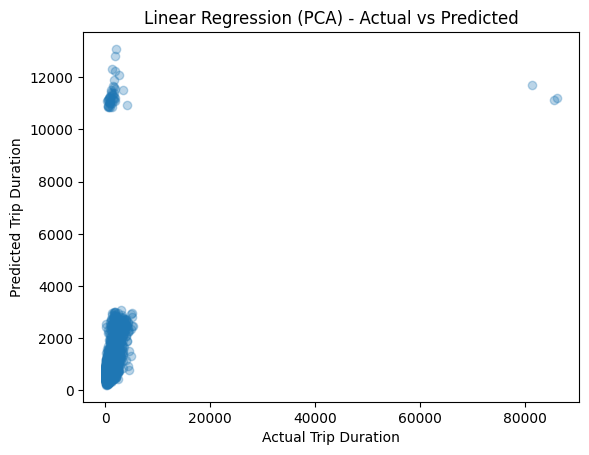

In [30]:
import matplotlib.pyplot as plt
#plotting the data
plt.figure()
plt.scatter(y_test[:5000], y_pred_test[:5000], alpha=0.3)
plt.xlabel("Actual Trip Duration")
plt.ylabel("Predicted Trip Duration")
plt.title("Linear Regression (PCA) - Actual vs Predicted")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
#same testing without the pca splitting the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression
#linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred_train = lr.predict(X_train)
y_pred_val = lr.predict(X_val)
y_pred_test = lr.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#evaluating the model
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")
evaluate(y_test, y_pred_test, "Test")


Train
MAE  : 517.6655
RMSE : 2943.1532
R2   : 0.1453

Validation
MAE  : 513.4840
RMSE : 2885.1820
R2   : 0.1418

Test
MAE  : 518.7980
RMSE : 2931.8325
R2   : 0.1438


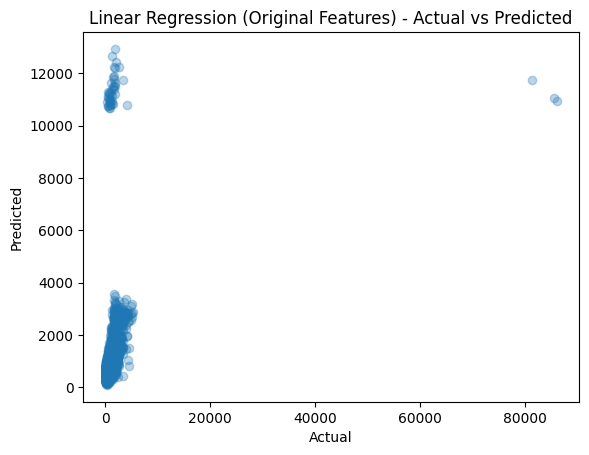

In [35]:
import matplotlib.pyplot as plt
#ploting the results
plt.figure()
plt.scatter(y_test[:5000], y_pred_test[:5000], alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression (Original Features) - Actual vs Predicted")
plt.show()

The linear regression model without PCA slightly outperforms the PCA-based version across all evaluation metrics. It achieves lower MAE and RMSE, and a marginally higher R² score, indicating better predictive accuracy and variance explanation. However, the improvement is minimal, suggesting that PCA does not significantly impact model performance in this case. This implies that the original feature space already retains useful predictive information, and dimensionality reduction via PCA may lead to slight information loss rather than performance gains for linear regression on this dataset.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
#using random forests
param_grid = {
    "n_estimators": [100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}
#hyperparameter tuning

print("START GRID SEARCH\n")

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for s in param_grid["min_samples_split"]:
            for l in param_grid["min_samples_leaf"]:
#creating random forest
                rf = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_split=s,
                    min_samples_leaf=l,
                    random_state=42,
                    n_jobs=-1
                )
 #training the random forests               

                rf.fit(X_train, y_train)

                val_pred = rf.predict(X_val)
# evaluating on the validation data
                mae = mean_absolute_error(y_val, val_pred)
                rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                r2 = r2_score(y_val, val_pred)

                print(f"n_estimators={n}, max_depth={d}, "
                      f"min_samples_split={s}, min_samples_leaf={l}")

                print("MAE :", mae)
                print("RMSE:", rmse)
                print("R2  :", r2)
                print("-" * 50)

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
# trying more number of of tree with the best configuration from 100 to search for optimal performance
param_grid = {
    "n_estimators": [200,300],
    "max_depth": [20],
    "min_samples_split": [10],
    "min_samples_leaf": [10]
}
#checking if 
print("START GRID SEARCH\n")

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for s in param_grid["min_samples_split"]:
            for l in param_grid["min_samples_leaf"]:

                rf = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_split=s,
                    min_samples_leaf=l,
                    random_state=42,
                    n_jobs=-1
                )#creating the forests

                rf.fit(X_train, y_train)

                val_pred = rf.predict(X_val)
#evaluating the forests
                mae = mean_absolute_error(y_val, val_pred)
                rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                r2 = r2_score(y_val, val_pred)

                print(f"n_estimators={n}, max_depth={d}, "
                      f"min_samples_split={s}, min_samples_leaf={l}")

                print("MAE :", mae)
                print("RMSE:", rmse)
                print("R2  :", r2)
                print("-" * 50)

START GRID SEARCH

n_estimators=200, max_depth=20, min_samples_split=10, min_samples_leaf=10
MAE : 206.516361844916
RMSE: 949.1963261780168
R2  : 0.9071166578526388
--------------------------------------------------
n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=10
MAE : 206.4997747388486
RMSE: 949.4297845368001
R2  : 0.9070709622284643
--------------------------------------------------


In [10]:
#patterns 
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1438951 entries, 0 to 1438950
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   vendor_id              1438951 non-null  int64  
 1   passenger_count        1438951 non-null  int64  
 2   pickup_longitude       1438951 non-null  float64
 3   pickup_latitude        1438951 non-null  float64
 4   dropoff_longitude      1438951 non-null  float64
 5   dropoff_latitude       1438951 non-null  float64
 6   pickup_hour            1438951 non-null  int64  
 7   pickup_day             1438951 non-null  int64  
 8   pickup_month           1438951 non-null  int64  
 9   pickup_day_of_week     1438951 non-null  int64  
 10  is_weekend             1438951 non-null  int64  
 11  cross_day_trip         1438951 non-null  int64  
 12  p_average_temperature  1438951 non-null  float64
 13  p_precipitation        1438951 non-null  float64
 14  p_snow_fall            143895

Shape: (1438951, 22)
vendor_id                0
passenger_count          0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
pickup_hour              0
pickup_day               0
pickup_month             0
pickup_day_of_week       0
is_weekend               0
cross_day_trip           0
p_average_temperature    0
p_precipitation          0
p_snow_fall              0
p_snow_depth             0
d_average_temperature    0
d_precipitation          0
d_snow_fall              0
d_snow_depth             0
trip_distance_km         0
trip_duration            0
dtype: int64


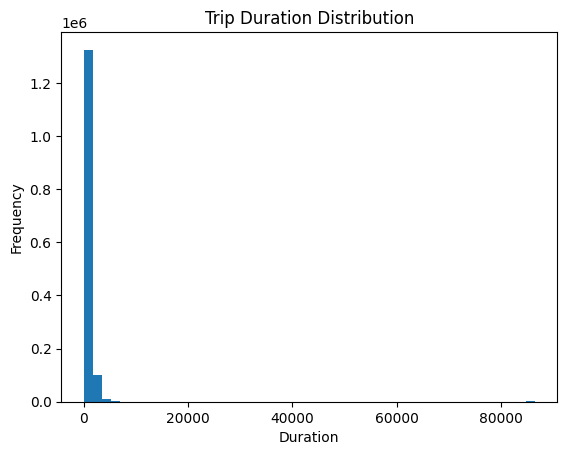

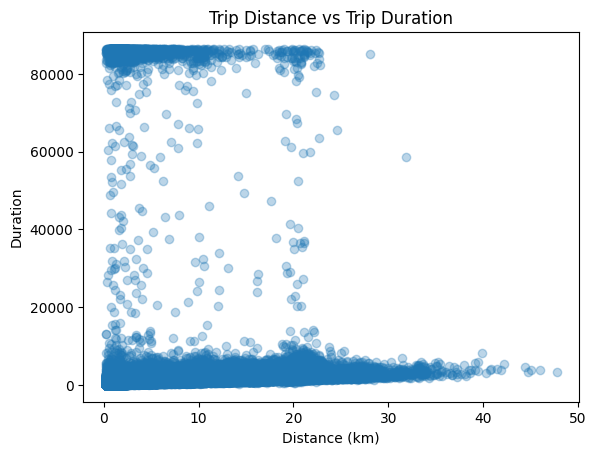

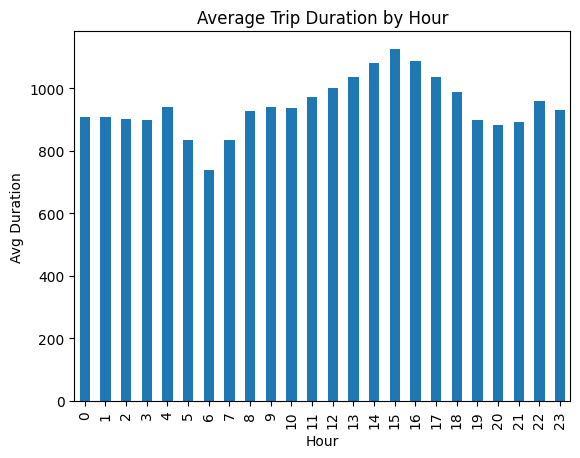

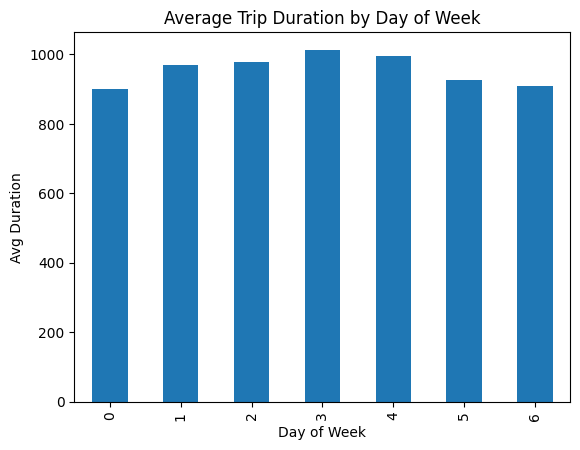

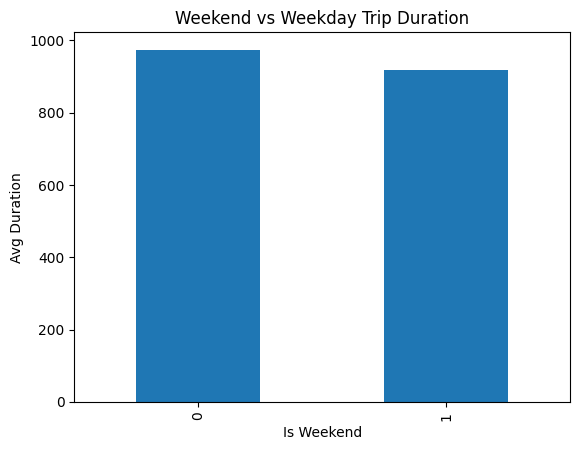

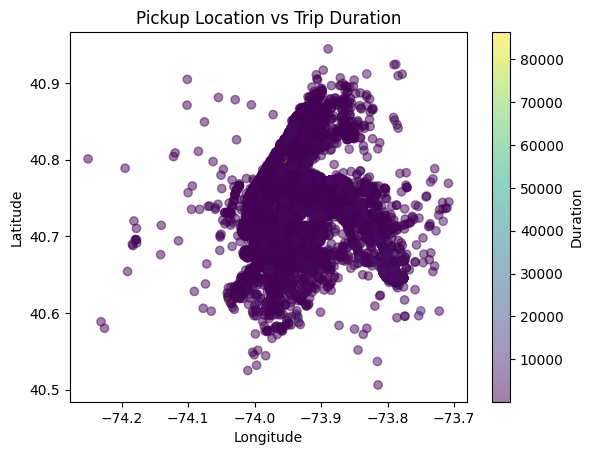

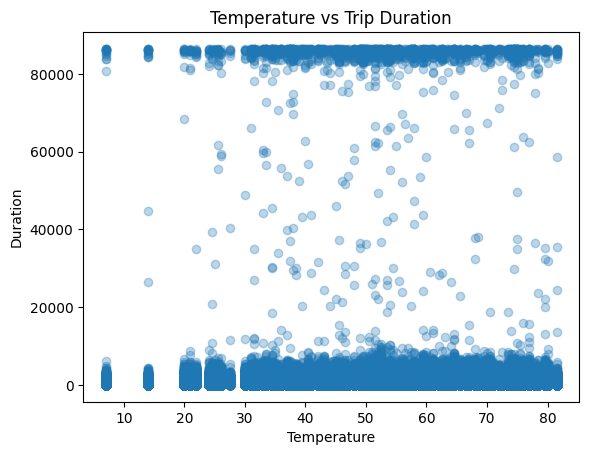

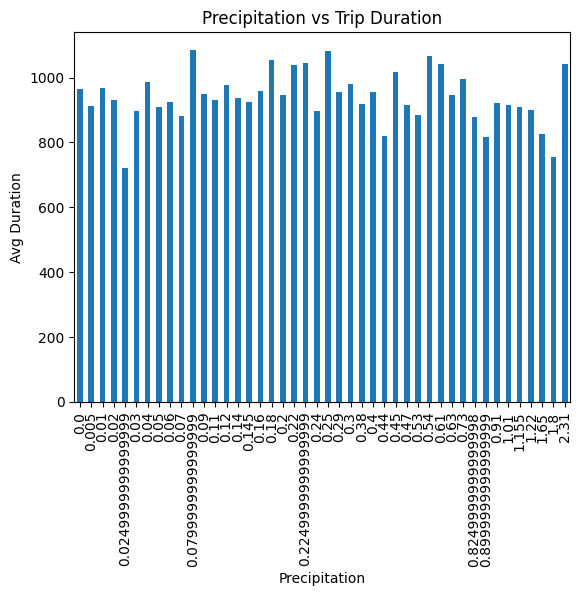

In [8]:
import matplotlib.pyplot as plt

# =========================
# 1. BASIC CHECK
# =========================
print("Shape:", combined_df.shape)
print(combined_df.isnull().sum())

# =========================
# 2. TRIP DURATION DISTRIBUTION
# =========================
plt.figure()
plt.hist(combined_df["trip_duration"], bins=50)
plt.title("Trip Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

# =========================
# 3. DISTANCE vs DURATION
# =========================
plt.figure()
plt.scatter(combined_df["trip_distance_km"], combined_df["trip_duration"], alpha=0.3)
plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Distance (km)")
plt.ylabel("Duration")
plt.show()

# =========================
# 4. TIME PATTERNS
# =========================
plt.figure()
combined_df.groupby("pickup_hour")["trip_duration"].mean().plot(kind="bar")
plt.title("Average Trip Duration by Hour")
plt.xlabel("Hour")
plt.ylabel("Avg Duration")
plt.show()

plt.figure()
combined_df.groupby("pickup_day_of_week")["trip_duration"].mean().plot(kind="bar")
plt.title("Average Trip Duration by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Avg Duration")
plt.show()

plt.figure()
combined_df.groupby("is_weekend")["trip_duration"].mean().plot(kind="bar")
plt.title("Weekend vs Weekday Trip Duration")
plt.xlabel("Is Weekend")
plt.ylabel("Avg Duration")
plt.show()

# =========================
# 5. SPATIAL PATTERN
# =========================
plt.figure()
plt.scatter(
    combined_df["pickup_longitude"],
    combined_df["pickup_latitude"],
    c=combined_df["trip_duration"],
    cmap="viridis",
    alpha=0.5
)
plt.title("Pickup Location vs Trip Duration")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Duration")
plt.show()

# =========================
# 6. WEATHER EFFECT
# =========================
plt.figure()
plt.scatter(combined_df["p_average_temperature"], combined_df["trip_duration"], alpha=0.3)
plt.title("Temperature vs Trip Duration")
plt.xlabel("Temperature")
plt.ylabel("Duration")
plt.show()

plt.figure()
combined_df.groupby("p_precipitation")["trip_duration"].mean().plot(kind="bar")
plt.title("Precipitation vs Trip Duration")
plt.xlabel("Precipitation")
plt.ylabel("Avg Duration")
plt.show()

In [9]:
import numpy as np

# =========================
# 1. BASIC STATISTICS
# =========================
print("SHAPE:", combined_df.shape)
print("\nMISSING VALUES:\n", combined_df.isnull().sum())

print("\nTRIP DURATION STATS:")
print(combined_df["trip_duration"].describe())

print("\nTRIP DISTANCE STATS:")
print(combined_df["trip_distance_km"].describe())

# =========================
# 2. CORE RELATIONSHIP (KEY PATTERN)
# =========================
corr_distance_duration = combined_df["trip_distance_km"].corr(combined_df["trip_duration"])
print("\nCorrelation (Distance vs Duration):", corr_distance_duration)

# =========================
# 3. TIME BASED PATTERNS
# =========================
print("\nAvg Duration by Hour:")
print(combined_df.groupby("pickup_hour")["trip_duration"].mean())

print("\nAvg Duration by Day of Week:")
print(combined_df.groupby("pickup_day_of_week")["trip_duration"].mean())

print("\nWeekend vs Weekday Avg Duration:")
print(combined_df.groupby("is_weekend")["trip_duration"].mean())

# =========================
# 4. WEATHER PATTERNS
# =========================
print("\nAvg Duration by Precipitation:")
print(combined_df.groupby("p_precipitation")["trip_duration"].mean())

print("\nCorrelation Temperature vs Duration:")
print(combined_df["p_average_temperature"].corr(combined_df["trip_duration"]))

# =========================
# 5. SPATIAL PATTERN SUMMARY
# =========================
print("\nPickup Longitude stats:")
print(combined_df["pickup_longitude"].describe())

print("\nPickup Latitude stats:")
print(combined_df["pickup_latitude"].describe())

# =========================
# 6. KEY INSIGHTS (AUTO SUMMARY)
# =========================
print("\n--- KEY PATTERNS SUMMARY ---")

print("1. Distance-Duration relationship strength:", corr_distance_duration)

print("2. Peak hour duration:", combined_df.groupby("pickup_hour")["trip_duration"].mean().max())

print("3. Lowest hour duration:", combined_df.groupby("pickup_hour")["trip_duration"].mean().min())

print("4. Weekend effect (diff):",
      combined_df.groupby("is_weekend")["trip_duration"].mean().diff().iloc[-1])

SHAPE: (1438951, 22)

MISSING VALUES:
 vendor_id                0
passenger_count          0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
pickup_hour              0
pickup_day               0
pickup_month             0
pickup_day_of_week       0
is_weekend               0
cross_day_trip           0
p_average_temperature    0
p_precipitation          0
p_snow_fall              0
p_snow_depth             0
d_average_temperature    0
d_precipitation          0
d_snow_fall              0
d_snow_depth             0
trip_distance_km         0
trip_duration            0
dtype: int64

TRIP DURATION STATS:
count    1.438951e+06
mean     9.581060e+02
std      3.170975e+03
min      6.000000e+01
25%      4.030000e+02
50%      6.670000e+02
75%      1.079000e+03
max      8.639200e+04
Name: trip_duration, dtype: float64

TRIP DISTANCE STATS:
count    1.438951e+06
mean     3.466213e+00
std      3.890200e+00
min      2.000024e-01
25%      1

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [12]:
X = combined_df.drop(columns=["trip_duration"])
y = combined_df["trip_duration"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
#training the final model for evaluation
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
import numpy as np
import pandas as pd
#failure analysis
# Predictions
y_pred = rf.predict(X_test)

# Build analysis dataframe
test_df = X_test.copy()
test_df["actual"] = y_test.values
test_df["predicted"] = y_pred
test_df["error"] = np.abs(test_df["actual"] - test_df["predicted"])

print("FAILURE RATE:", np.mean(test_df["error"] / test_df["actual"]))

# ---------------- TIME BASED ERRORS ----------------
print("\nERROR BY HOUR")
print(test_df.groupby("pickup_hour")["error"].mean())

print("\nERROR BY DAY OF WEEK")
print(test_df.groupby("pickup_day_of_week")["error"].mean())

print("\nERROR BY MONTH")
print(test_df.groupby("pickup_month")["error"].mean())

print("\nWEEKEND VS WEEKDAY ERROR")
print(test_df.groupby("is_weekend")["error"].mean())

# ---------------- OPERATIONAL FACTORS ----------------
print("\nERROR BY PASSENGER COUNT")
print(test_df.groupby("passenger_count")["error"].mean())

print("\nERROR BY VENDOR")
print(test_df.groupby("vendor_id")["error"].mean())

print("\nERROR BY TRIP DISTANCE BINS")
test_df["distance_bin"] = pd.cut(test_df["trip_distance_km"], bins=5)
print(test_df.groupby("distance_bin")["error"].mean())

# ---------------- WEATHER EFFECTS ----------------
print("\nERROR BY PRECIPITATION (PICKUP)")
print(test_df.groupby("p_precipitation")["error"].mean())

print("\nERROR BY TEMPERATURE (PICKUP)")
print(test_df.groupby("p_average_temperature")["error"].mean())

print("\nERROR BY SNOW CONDITIONS (PICKUP)")
print(test_df.groupby("p_snow_fall")["error"].mean())

# ---------------- EXTREME FAILURES ----------------
print("\nTOP 10% WORST PREDICTIONS")
print(test_df.sort_values("error", ascending=False).head(int(0.1 * len(test_df))))

FAILURE RATE: 0.29054892385885683

ERROR BY HOUR
pickup_hour
0     197.224319
1     167.704976
2     148.331339
3     167.534255
4     165.479586
5     168.636200
6     146.366313
7     185.531583
8     200.349804
9     202.986065
10    203.866811
11    208.283958
12    210.854722
13    225.227073
14    219.119720
15    225.394918
16    236.569041
17    208.735592
18    205.692744
19    178.799606
20    170.897052
21    172.742181
22    209.876142
23    384.283488
Name: error, dtype: float64

ERROR BY DAY OF WEEK
pickup_day_of_week
0    197.123440
1    199.047365
2    209.616305
3    219.275321
4    225.738136
5    202.024150
6    193.729463
Name: error, dtype: float64

ERROR BY MONTH
pickup_month
1    200.770845
2    194.339566
3    201.276996
4    211.245315
5    217.304259
6    218.173976
Name: error, dtype: float64

WEEKEND VS WEEKDAY ERROR
is_weekend
0    210.827843
1    198.113336
Name: error, dtype: float64

ERROR BY PASSENGER COUNT
passenger_count
1    203.532322
2    212.66171

In [16]:
#final test metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 207.21098692556401
RMSE: 1002.4910907582794
R2  : 0.8983708418952255


## Task 3: Trip Duration Prediction and Model Comparison

#### Features
A comprehensive set of spatial, temporal, weather, and operational features was selected from the processed dataset, including vendor ID, passenger count, pickup and dropoff coordinates, time-based features (hour, day, month, day of week, weekend indicator, cross-day trip flag), weather attributes (temperature, precipitation, snow fall, snow depth for both pickup and dropoff), and trip distance. These features collectively capture travel behavior, environmental conditions, and spatial movement patterns affecting trip duration.

#### Target Variable
Trip duration was used as the continuous target variable representing total travel time between pickup and dropoff locations.

#### Data Preprocessing and Transformation
The feature set was standardized before modeling. Additionally, Principal Component Analysis (PCA) was applied to reduce dimensionality while preserving variance, and a comparison was made between PCA-transformed features and the original feature space to evaluate its impact on model performance.

#### Data Splitting Strategy
The dataset was split into training, validation, and testing sets using a 70%–15%–15% split to ensure unbiased evaluation and prevent data leakage.



#### Model Selection - Linear Regression
A Linear Regression model was used as the baseline regression approach. Two variants were tested: one trained on PCA-transformed features and another on the original feature space. This allowed comparison of the impact of dimensionality reduction on predictive performance.



#### Model Selection - Random Forest Regressor
A Random Forest Regressor was implemented to capture non-linear relationships in the data. The model was trained using grid search-based hyperparameter tuning.

###### Hyperparameter Optimization
Grid search was performed over multiple configurations including:
- n_estimators  
- max_depth  
- min_samples_split  
- min_samples_leaf  



#### Evaluation Metrics
Final model performance was assessed using:
- MAE (prediction error magnitude)  
- RMSE (penalized error for large deviations)  
- R² Score (variance explained by the model)  



## Task 3: Trip Duration Prediction (Evaluation)

#### PCA Result
Principal Component Analysis (PCA) was applied using 14 components capturing approximately **96.10% variance**. However, PCA did not improve model performance. Therefore, the original feature space was retained for final evaluation due to better interpretability and slightly better predictive accuracy.



#### Linear Regression Performance
- MAE: 518.7980  
- RMSE: 2931.8325  
- R²: 0.1438  



#### Random Forest Regressor Performance

###### Best Hyperparameters
- n_estimators: 200  
- max_depth: 20  
- min_samples_split: 10  
- min_samples_leaf: 10  

###### Performance
- MAE: 207.21098692556401  
- RMSE: 1002.4910907582794  
- R²: 0.8983708418952255  


#### Final Model Selection
The Random Forest Regressor significantly outperforms Linear Regression models. It achieves:
- Much lower error values (MAE and RMSE)  
- Very high explanatory power (R² ≈ 0.9)  

This indicates that trip duration has strong non-linear relationships with input features, which Linear Regression fails to capture effectively.


#### Interpretation and Patterns Observed
- Trip duration is better explained by non-linear relationships rather than linear trends  
- Linear models show low explanatory power (R² ≈ 0.14), indicating limited linear dependency in the dataset  
- Trip duration shows a clear time-of-day pattern, with lowest values in early morning hours and highest values in mid afternoon, indicating strong congestion effects during daytime  
- Weekdays generally have higher average trip duration than weekends, showing consistently higher delays during working days  
- Mid-week days show higher trip durations compared to the start and end of the week, indicating uneven traffic patterns  
- Trip duration increases during peak daytime hours and decreases during off-peak hours, showing strong variation based on traffic conditions  
- There are some extreme long duration trips in the dataset, which act as outliers and affect overall duration values  


#### Actionable Recommendations
- The final Random Forest model can be used by city transport authorities for accurate travel time estimation across urban routes, improving public travel planning and enabling more reliable prediction of trip durations under varying traffic conditions  
- It can support adaptive traffic management strategies by helping authorities adjust signal timings, manage congestion hotspots, and implement time-based traffic control during peak demand periods  
- Transport departments can use the model to improve fleet and route allocation for public transport systems by anticipating longer travel times in advance and optimizing service coverage across different city zones  


#### Failure Analysis and Limitations

The final Random Forest model shows a failure rate of around **0.29**, meaning nearly one-third of predictions are inaccurate. This indicates that while the model captures general trip duration patterns, it struggles under complex and highly variable conditions.

Errors are higher during late-night and peak daytime hours, where traffic conditions change rapidly, while early morning hours show lower error, reflecting better performance in stable traffic conditions.

Across days of the week, errors are slightly higher during mid-week and late-week periods, suggesting that irregular travel behavior reduces prediction accuracy compared to more stable periods.

The model also shows increasing error in later months, indicating that seasonal variation and changing travel demand patterns affect performance.

Long-distance trips show significantly higher error compared to short trips, highlighting difficulty in handling route variability and traffic uncertainty over longer journeys. Similarly, higher passenger count trips show more deviation, indicating added complexity in group travel scenarios.

Weather extremes such as heavy rainfall and snowfall conditions also increase prediction errors, showing limited model robustness under rare environmental conditions.

Overall, the model fails most in high-variability situations such as peak hours, long trips, extreme weather, and irregular travel patterns, while performing better in stable and routine conditions.